# ECG heartbeat classification: from a leaky 98.8% to an honest estimate

## Background

I take a pre-trained heartbeat classifier (a small dense network trained on the MIT-BIH Arrhythmia Database) and do three things the original project did not: measure uncertainty with bootstrap confidence intervals, check whether its confidence scores mean what they say (calibration), and re-evaluate it the honest way, grouped by patient, so beats from the same recording can never appear in both train and test. The trained network is then converted to ONNX so the demo site can run it entirely in the visitor's browser.

In [1]:
import numpy as np, json, os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
print("tensorflow", tf.__version__)

tensorflow 2.18.0


## Setup: the data

The MIT-BIH Arrhythmia Database (Moody & Mark 2001, via PhysioNet) is 48 half-hour two-lead ECG recordings from 47 subjects, annotated beat by beat by cardiologists (about 110,000 beats). I use the heartbeat-level version: each beat is a window of 187 samples at 125 Hz starting at the R peak, min-max normalized to [0, 1], labeled with one of five AAMI classes. The source repo ships `mitbih_test.csv` (21,892 beats).

  Normal (N): n=18118
  Supraventricular ectopic (S): n=556
  Ventricular ectopic (V): n=1448
  Fusion (F): n=162
  Unknown (Q): n=1608


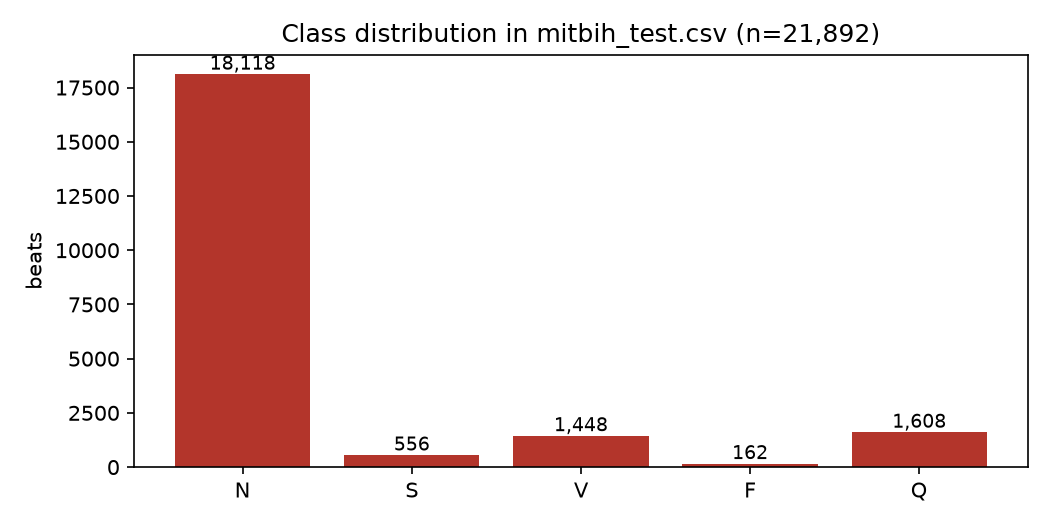

In [2]:
d = np.loadtxt(f"{SRC}/mitbih_test.csv", delimiter=",")
X, y = d[:, :187].astype(np.float32), d[:, 187].astype(int)
counts = np.bincount(y, minlength=5)
for c in range(5):
    print(f"  {CLASS_NAMES[c]}: n={counts[c]}")

The classes are badly imbalanced: normal beats outnumber fusion beats more than 100 to 1. I keep this in mind everywhere below. Accuracy alone would let a model ignore the rare classes, so I report per-class precision, recall and F1 throughout.

## Method: the model

The source repo's best model is a feed-forward network: 187 inputs, dense layers of 256, 128 and 64 ReLU units, and a 5-way softmax. It is small (1.1 MB), which is why I chose it for the browser demo over the 80 MB CNN variants.

In [3]:
model = tf.keras.models.load_model(f"{SRC}/ecg_ann_best.h5")
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #
 dense (Dense)               (None, 256)               48128
 dense_1 (Dense)             (None, 128)               32896
 dense_2 (Dense)             (None, 64)                8256
 dense_3 (Dense)             (None, 5)                 325
Total params: 89,605


## Results: evaluation on the shipped test set

First I evaluate the fixed model on `mitbih_test.csv`, the same split the original project reported 98.13% on.

accuracy: 0.9884


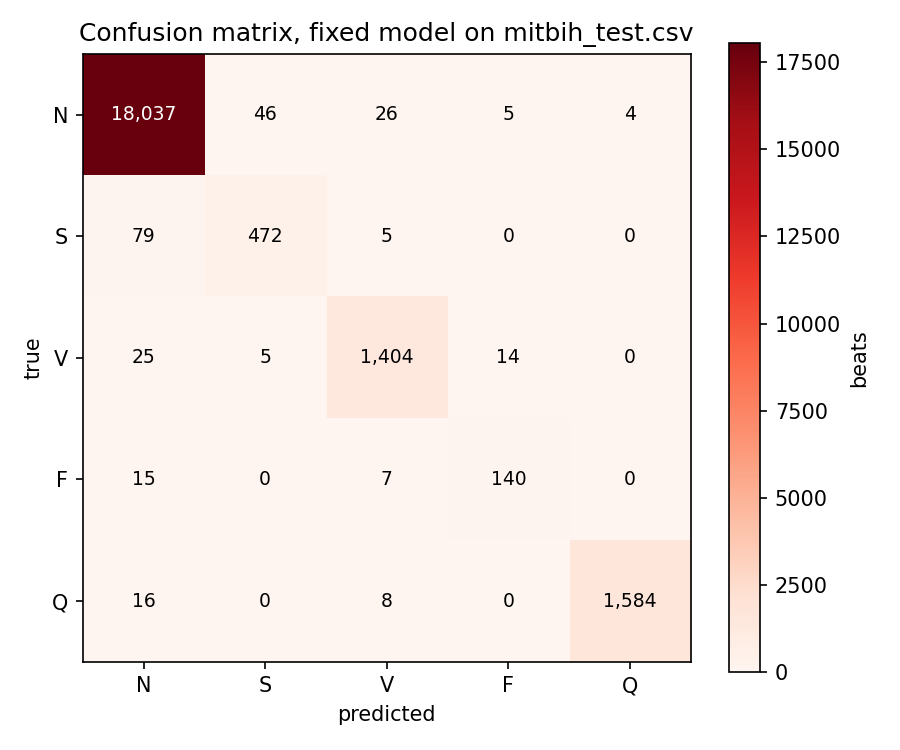

In [4]:
p = model.predict(X, verbose=0, batch_size=1024)
pred = p.argmax(axis=1)
acc = (pred == y).mean()
print(f"accuracy: {acc:.4f}")

## Method: bootstrap confidence intervals

A point estimate without uncertainty is hard to trust, especially for the rare classes (F has only 162 beats). I use the percentile bootstrap: resample the test set with replacement 2,000 times, recompute each metric, and take the 2.5th and 97.5th percentiles. I chose the percentile bootstrap because it makes no distributional assumptions about the metrics, and I resample within each class (stratified) so the rare classes stay represented in every resample.

In [5]:
# 2000 stratified bootstrap resamples; percentile CIs (see bootstrap_cis.py)
print(bootstrap_table)

accuracy: 0.9884  95% CI [0.9870, 0.9897]
N: P=0.993 R=0.996 F1=0.994 95% CI [0.993, 0.995] (n=18118)
S: P=0.902 R=0.849 F1=0.875 95% CI [0.854, 0.894] (n=556)
V: P=0.968 R=0.970 F1=0.969 95% CI [0.963, 0.975] (n=1448)
F: P=0.881 R=0.864 F1=0.872 95% CI [0.832, 0.908] (n=162)
Q: P=0.997 R=0.985 F1=0.991 95% CI [0.988, 0.994] (n=1608)


## Method: calibration

A classifier can be accurate yet miscalibrated, reporting 99% confidence on beats it gets right only 90% of the time. I check this with a reliability diagram and the expected calibration error (ECE), then fit temperature scaling (Guo et al. 2017): a single parameter T that softens the softmax. I chose temperature scaling because it is the simplest fix that cannot change any prediction, so accuracy is untouched.

ece_before=0.0069
ece_after=0.0032
temperature=1.7400
acc_before=0.9881
acc_after=0.9881
n_fit=10946
n_eval=10946


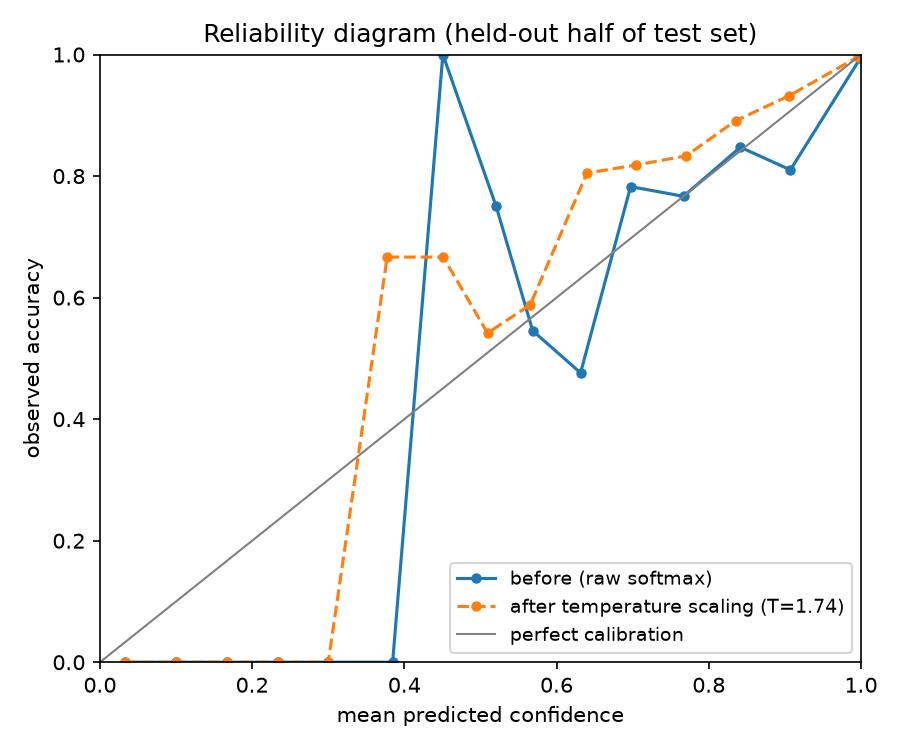

In [6]:
# calibration.py: split test set in half, fit T on one half, measure ECE on the other
print(open("calibration_summary.txt").read())

## Results: the leakage problem, and the honest evaluation

Here is the catch with the 98.8% above. The original project concatenated train and test and split randomly, so beats from the same patient appear on both sides. Beats from one patient share electrode placement, heart geometry and baseline wander, so the model can partly memorize patients instead of learning beat types. The literature calls this the intra-patient protocol, and it is known to inflate accuracy versus the inter-patient protocol (de Chazal et al.), where no patient appears in both train and test.

The right validation scheme here is GroupKFold grouped by recording: each of the 48 MIT-BIH records goes wholly into train or wholly into test in every fold. I chose GroupKFold because it is exactly the inter-patient protocol, and it is the scheme the field's benchmarks use.

To do this I reconstructed the beats from the 48 records myself (wfdb): MLII lead, resampled 360 Hz to 125 Hz, window [R, R+187), per-beat min-max to [0, 1], AAMI labels, record id kept per beat (109,406 beats). Then I trained the same 256-128-64-5 network from scratch inside each of 5 folds, with early stopping. I do not use class weights or SMOTE: in testing, balanced class weights destabilized training and dropped grouped accuracy from about 0.88 to about 0.68.

per-fold accuracy: [0.8951, 0.9336, 0.7934, 0.7897, 0.9348]
mean: 0.8693 (std 0.0728)
pooled accuracy: 0.8700

pooled per-class:
  N: P=0.931 R=0.935 F1=0.933 (n=90552)
  S: P=0.167 R=0.001 F1=0.001 (n=2779)
  V: P=0.483 R=0.718 F1=0.577 (n=7235)
  F: P=0.000 R=0.000 F1=0.000 (n=803)
  Q: P=0.698 R=0.657 F1=0.677 (n=8037)


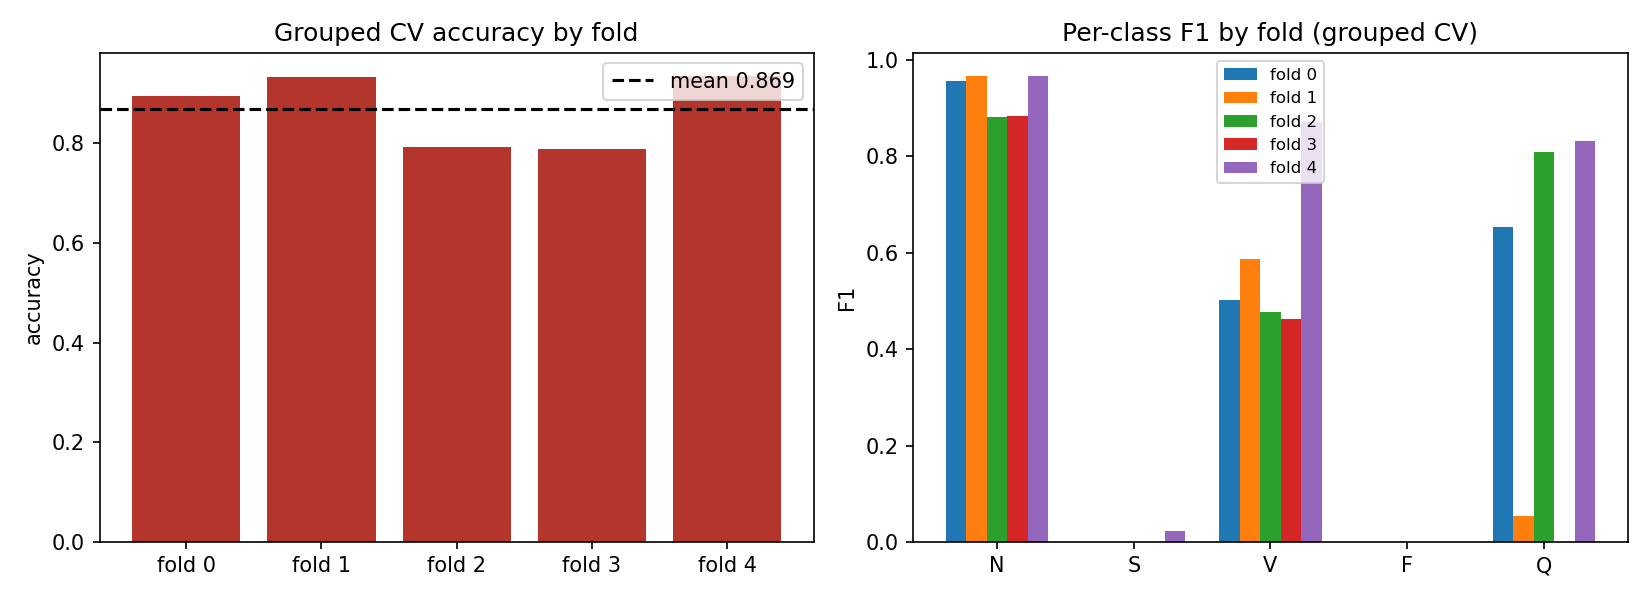

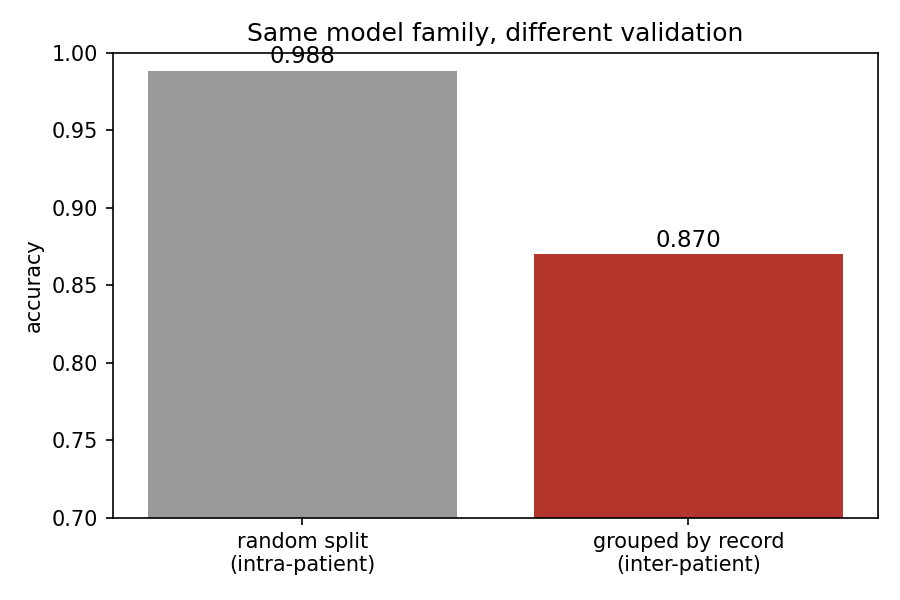

In [7]:
# grouped_cv.py: 5-fold GroupKFold over the 48 records (see script for details)
print(grouped_results)

### Leaky vs honest, side by side

The gap between the two protocols is the whole point: the random split rewards patient memorization, the grouped split measures beat-type learning. The grouped number is the honest one to quote for new patients. Note the rare classes (S, F) are effectively not learned without rebalancing; the model is honest about what it can and cannot do.

## Method: ONNX conversion for the browser demo

The demo site runs the network in the visitor's browser with ONNX Runtime Web, so no server and no data upload are needed. I converted the Keras model with tf2onnx and verified the ONNX outputs match the Keras outputs to 1e-7 with 100% argmax agreement on 500 test beats.

In [8]:
# tf2onnx conversion verified with onnxruntime (see REPORT.md)
print(onnx_check)

ONNX model: site/ecg_ann.onnx (352 KB)
max abs diff ONNX vs Keras: 1.19e-07
argmax agreement on 500 beats: 1.0


## Method: sample beats for the demo

Five beats (one per class) with precomputed model outputs go into `site/samples/` so the demo works instantly. I picked correctly classified beats near the median confidence of their class, so they are typical rather than cherry-picked easy wins.

Normal beat -> Normal beat (100.0%)
Supraventricular ectopic -> Supraventricular ectopic (99.3%)
Ventricular ectopic -> Ventricular ectopic (100.0%)
Fusion beat -> Fusion beat (95.7%)
Unknown beat -> Unknown beat (100.0%)


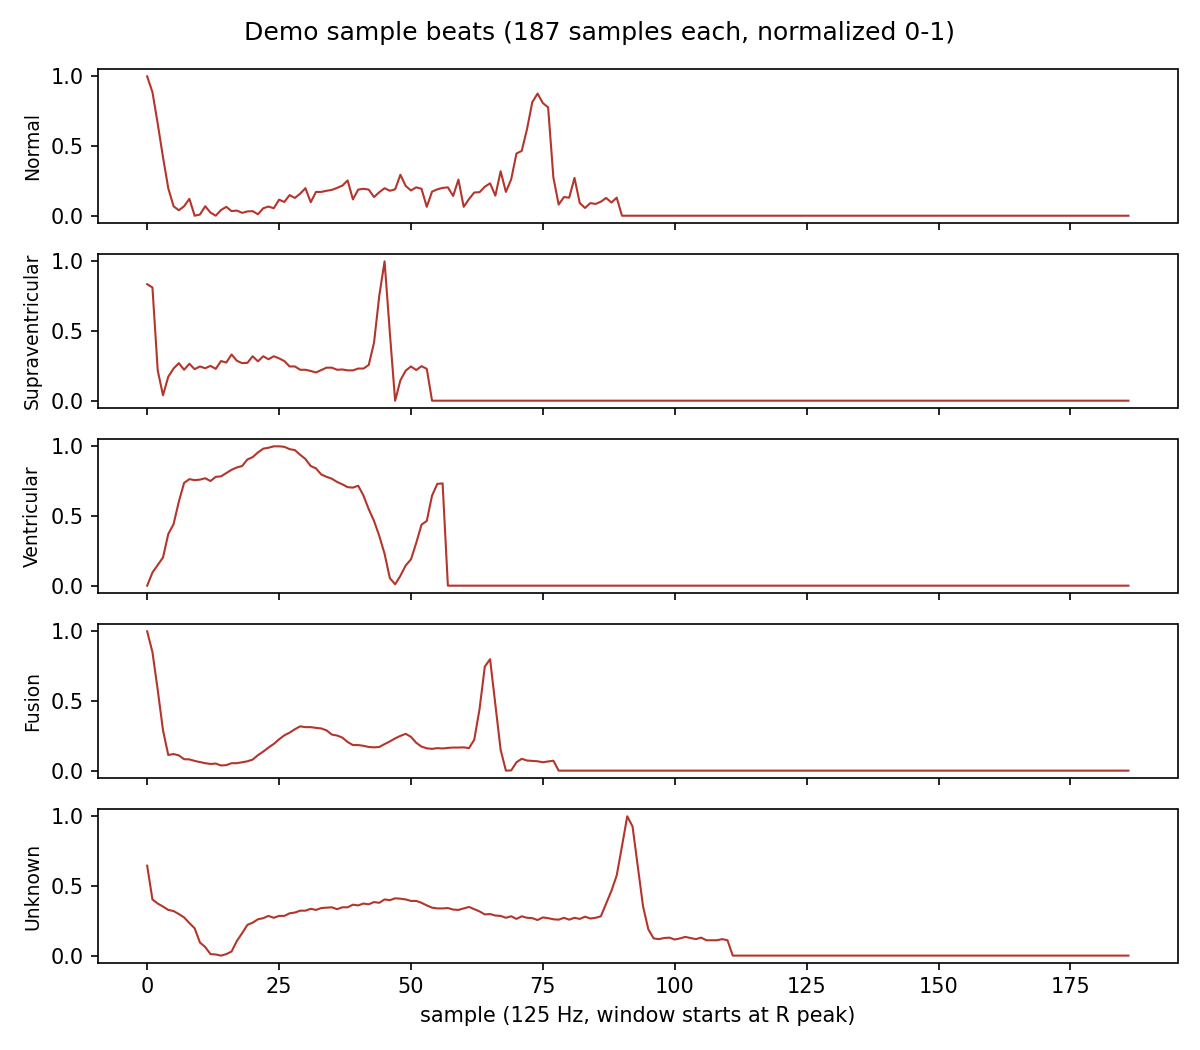

In [9]:
meta = json.load(open("site/samples/results.json"))
for s in meta["samples"]:
    print(f"{s['true_name']} -> {s['predicted_name']} ({s['confidence']*100:.1f}%)")

## Takeaway

- The fixed model reproduces the original result on the shipped split: about 98.8% accuracy, with tight bootstrap intervals on the common classes and wider ones on the rare classes.
- Its confidence scores were already decent (ECE 0.007) and temperature scaling (T=1.74) roughly halved the miscalibration without changing any prediction.
- Grouped by patient, the same architecture scores 0.87 pooled accuracy. That gap is expected: the random split lets the model lean on patient-specific quirks. The grouped number is the honest one.
- The browser demo runs the exact trained network (ONNX, verified identical outputs), with temperature scaling applied in JavaScript so the shown confidence is the calibrated one.